# 02 — EDA: orders and unit economics

Notebook 01 established that the randomisation is sound and that the nudge **costs**
conversion. This notebook looks at the other side of the trade: what happens to the
basket, and whether the extra basket pays for the delivery QuickBasket gives away.

`qb_orders.csv` holds two things:

* `phase == "post"` — every order placed during the four experiment weeks.
* `phase == "pre"` — two weeks of order history for a loyal cohort, generated *before*
  launch. Nobody is treated in the pre period; it exists so notebook 04 can run a paired
  t-test and a control-arm placebo.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"  # Arial has no rupee glyph

FREE_DELIVERY_THRESHOLD = 499.0

orders = pd.read_csv(Path("../data/qb_orders.csv"), parse_dates=["order_ts"])
sessions = (
    pd.read_csv(Path("../data/qb_cart_sessions.csv"), parse_dates=["session_ts"])
    .drop_duplicates(subset="session_id")
)
orders.shape, sessions.shape

/var/folders/0l/6zfkt4257nx_lmh9vlt1l2gw0000gn/T/ipykernel_25191/1488666555.py:16: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv(Path("../data/qb_orders.csv"), parse_dates=["order_ts"])


((70472, 13), (160000, 10))

In [2]:
orders.head()

,order_id,session_id,user_id,group,city_tier,phase,order_ts,items_count,basket_value_inr,free_delivery_unlocked,delivery_fee_charged_inr,delivery_cost_inr,gross_margin_inr
0,O0000001,S0003211,U007043,control,metro,post,2026-02-02 00:09:27,3,333.47,0,35.00,33.07,46.60
1,O0000002,S0155253,U073222,control,tier_3,post,2026-02-02 00:12:53,5,229.83,0,35.00,52.78,34.50
2,O0000003,S0114016,U103578,control,metro,post,2026-02-02 00:17:06,1,96.57,0,35.00,53.64,16.45
3,O0000004,S0070923,U154915,control,metro,post,2026-02-02 00:20:33,6,668.21,1,0.00,43.13,137.90
4,O0000005,S0118092,U143737,treatment,tier_3,post,2026-02-02 00:23:28,3,253.71,0,35.00,46.01,48.50


In [3]:
orders.groupby("phase").agg(orders=("order_id", "size"), users=("user_id", "nunique"))

,orders,users
phase,,
post,52879,52879
pre,17593,3200


## 1. Join integrity

The sessions table says how many orders *should* exist. The orders table says how many
do. Any gap between the two is a pipeline problem, and it matters here because notebook
04 builds revenue per session by joining these tables — a session that converted but has no
order row would silently be counted as ₹0 revenue.

In [4]:
post = orders[orders["phase"] == "post"]
converted_sessions = set(sessions.loc[sessions["order_placed"] == 1, "session_id"])
order_sessions = set(post["session_id"])

print(f"sessions marked converted : {len(converted_sessions):,}")
print(f"post-period order rows    : {len(post):,}")
print(f"orphan sessions (no order): {len(converted_sessions - order_sessions):,}")
print(f"orphan orders (no session): {len(order_sessions - converted_sessions):,}")

sessions marked converted : 53,129
post-period order rows    : 52,879
orphan sessions (no order): 250
orphan orders (no session): 0


250 converted sessions never produced an order row. Two possible readings:

* **Fill them with ₹0.** Wrong — it asserts the user bought nothing, which the session
  table directly contradicts. It would bias revenue per user downward.
* **Drop those sessions from both the numerator and the denominator.** Correct, provided
  the loss is unrelated to the arm. 250 rows on 160,000 is 0.16%, and the split below is
  even — so it is missing-completely-at-random and dropping is unbiased.

Notebook 04 drops them. The check that licenses that decision:

In [5]:
orphans = sessions[sessions["session_id"].isin(converted_sessions - order_sessions)]
orphans["group"].value_counts()

group
control      130
treatment    120
Name: count, dtype: int64

## 2. Cleaning

Missing baskets first, then outliers.

In [6]:
print(orders.isna().sum())
print(f"\nmissing basket_value_inr: {orders['basket_value_inr'].isna().sum()} "
      f"({orders['basket_value_inr'].isna().mean():.2%})")
orders.loc[orders["basket_value_inr"].isna(), "group"].value_counts()

order_id                        0
session_id                  17593
user_id                         0
group                           0
city_tier                       0
phase                           0
order_ts                        0
items_count                     0
basket_value_inr              211
free_delivery_unlocked          0
delivery_fee_charged_inr        0
delivery_cost_inr               0
gross_margin_inr                0
dtype: int64

missing basket_value_inr: 211 (0.30%)


group
control      114
treatment     97
Name: count, dtype: int64

~0.3% of baskets failed to serialise, split evenly across arms. Same argument as the
orphans: drop, do not impute. Imputing the mean here would shrink the variance and
artificially narrow every confidence interval downstream.

In [7]:
clean = orders.dropna(subset=["basket_value_inr"]).copy()
print(f"{len(orders):,} -> {len(clean):,} orders")

70,472 -> 70,261 orders


In [8]:
post = clean[clean["phase"] == "post"]
q1, q3 = post["basket_value_inr"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

print(f"Q1 {q1:,.0f}   Q3 {q3:,.0f}   IQR {iqr:,.0f}   upper fence {upper_fence:,.0f}")
print(f"orders above the fence: {(post['basket_value_inr'] > upper_fence).sum():,} "
      f"({(post['basket_value_inr'] > upper_fence).mean():.2%})")
post["basket_value_inr"].describe(percentiles=[0.5, 0.9, 0.99, 0.999])

Q1 266   Q3 616   IQR 350   upper fence 1,141
orders above the fence: 1,459 (2.77%)


count   52,730.00
mean       482.98
std        772.98
min         29.46
50%        422.17
90%        811.85
99%      1,406.70
99.9%    2,067.63
max     74,135.14
Name: basket_value_inr, dtype: float64

The largest order is roughly 35× the 99.9th percentile. Those are bulk buys —
offices and small shops restocking through the consumer app. They are **real orders**,
not corrupted rows, so removing them would be quietly deleting revenue that actually
happened.

The decision: keep them in the primary analysis, and re-run the test with them trimmed as
a robustness check in notebook 04. If both give the same answer, the conclusion does not
rest on twelve orders. Their real cost is variance — and variance is what a t-test
divides by, so they make the test *harder* to pass, not easier.

In [9]:
bulk = post.nlargest(12, "basket_value_inr")[["order_id", "group", "city_tier", "basket_value_inr"]]
print(f"bulk orders by arm: {bulk['group'].value_counts().to_dict()}")
bulk

bulk orders by arm: {'treatment': 6, 'control': 6}


,order_id,group,city_tier,basket_value_inr
6064,O0006065,treatment,metro,"74,135.14"
18915,O0018916,control,metro,"65,752.25"
21129,O0021130,control,tier_3,"60,353.91"
26328,O0026329,treatment,tier_2,"52,810.03"
42392,O0042393,treatment,metro,"51,993.97"
32392,O0032393,control,tier_2,"49,390.40"
19664,O0019665,control,metro,"40,938.61"
30765,O0030766,control,tier_3,"39,314.83"
23973,O0023974,treatment,metro,"37,728.86"
27253,O0027254,treatment,metro,"37,706.00"


## 3. Central tendency and dispersion of the basket

This is the metric experiment 2 tests, so its shape decides which test is legitimate.

In [10]:
summary = post.groupby("group")["basket_value_inr"].agg(
    n="size", mean="mean", median="median",
    std="std", iqr=lambda s: s.quantile(0.75) - s.quantile(0.25),
    skew="skew", kurtosis=lambda s: s.kurtosis(),
)
summary["cv"] = summary["std"] / summary["mean"]
summary.T

group,control,treatment
n,"27,281.00","25,449.00"
mean,447.30,521.23
median,383.68,525.36
std,748.98,796.13
iqr,300.27,365.46
skew,64.32,61.40
kurtosis,"4,865.07","4,674.42"
cv,1.67,1.53


Three things to read off this table:

1. **Mean > median in both arms.** Classic right skew — a long tail of large baskets
   pulls the mean above the middle of the distribution. The mean is still the right
   metric here because revenue is additive and the business cares about the total, but
   it is worth knowing the median moves less than the mean.
2. **The coefficient of variation is above 1 and the kurtosis is enormous**, both driven
   by the bulk orders. High CV means noisy — that is precisely why the experiment needs
   tens of thousands of observations per arm.
3. **Treatment's mean is well above control's.** Whether that gap is real is notebook
   04's job; here it just tells us where to look.

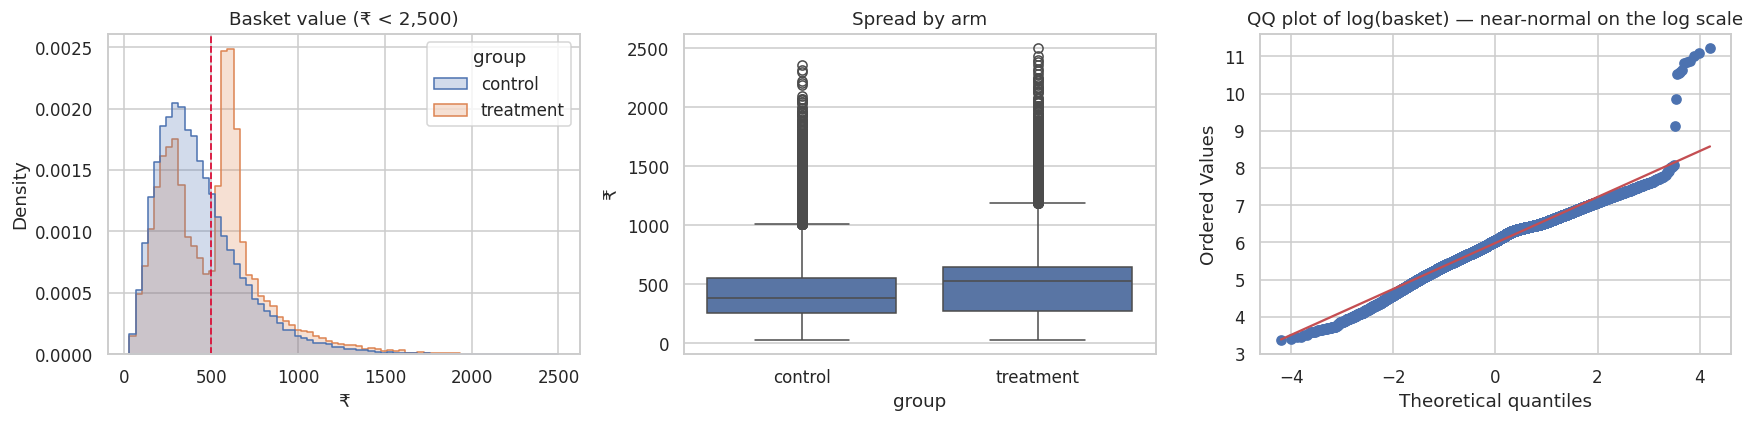

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=post[post["basket_value_inr"] < 2500], x="basket_value_inr", hue="group",
             bins=70, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].axvline(FREE_DELIVERY_THRESHOLD, color="crimson", ls="--", lw=1.2)
axes[0].set(title="Basket value (₹ < 2,500)", xlabel="₹")
sns.boxplot(data=post[post["basket_value_inr"] < 2500], x="group", y="basket_value_inr", ax=axes[1])
axes[1].set(title="Spread by arm", ylabel="₹")
stats.probplot(np.log(post["basket_value_inr"]), dist="norm", plot=axes[2])
axes[2].set_title("QQ plot of log(basket) — near-normal on the log scale")
plt.tight_layout()

The raw basket is skewed; its logarithm is close to normal. That is the signature of a
lognormal, and it motivates two things in notebook 04: **Welch's** t-test rather than
Student's (the arms need not share a variance), and a log-scale re-run as a robustness
check.

It does **not** mean the t-test is invalid. A t-test requires the *sampling distribution
of the mean* to be normal, not the data. At n ≈ 26,000 per arm the CLT delivers that
comfortably — a point notebook 04 verifies with a bootstrap.

## 4. Is the nudge actually working? Look at the threshold.

If the "Add ₹120 more" banner does what it is supposed to, treatment baskets should
*bunch* just above ₹499 — users topping up to clear the line. This is the most direct
visual evidence of a mechanism, and it is far more convincing than a p-value on the mean.

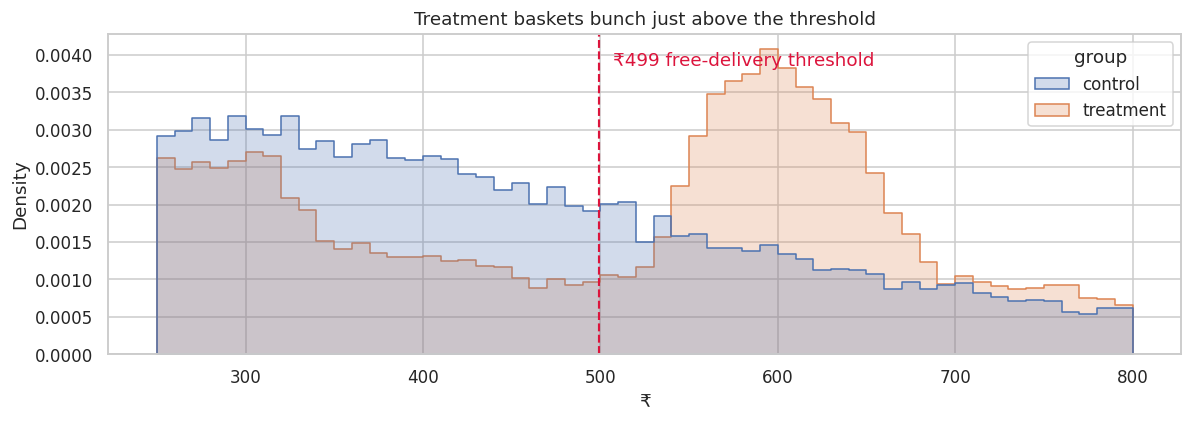

In [12]:
band = post[post["basket_value_inr"].between(250, 800)]
fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(data=band, x="basket_value_inr", hue="group", bins=55, element="step",
             stat="density", common_norm=False, ax=ax)
ax.axvline(FREE_DELIVERY_THRESHOLD, color="crimson", ls="--", lw=1.4)
ax.annotate("₹499 free-delivery threshold", (FREE_DELIVERY_THRESHOLD + 8, ax.get_ylim()[1] * 0.9),
            color="crimson")
ax.set(title="Treatment baskets bunch just above the threshold", xlabel="₹")
plt.tight_layout()

In [13]:
just_below = post["basket_value_inr"].between(400, FREE_DELIVERY_THRESHOLD)
just_above = post["basket_value_inr"].between(FREE_DELIVERY_THRESHOLD, 600)
pd.DataFrame({
    "share ₹400–499": post[just_below].groupby("group").size() / post.groupby("group").size(),
    "share ₹499–600": post[just_above].groupby("group").size() / post.groupby("group").size(),
    "free delivery unlocked": post.groupby("group")["free_delivery_unlocked"].mean(),
})

,share ₹400–499,share ₹499–600,free delivery unlocked
group,,,
control,0.15,0.11,0.32
treatment,0.07,0.17,0.52


The mechanism is visible: treatment drains the ₹400–499 band and fills ₹499–600, and the
share of orders unlocking free delivery jumps from ~32% to ~52%.

That last number is the warning shot. Every unlocked order is ₹35 of delivery revenue
QuickBasket no longer collects.

## 5. Unit economics, built one column at a time

Revenue is not the objective — **contribution margin** is. Build it explicitly:

```
margin = gross_margin_inr + delivery_fee_charged_inr − delivery_cost_inr
```

where `gross_margin_inr` is the product margin on the basket (~18%), the fee is ₹35
unless the basket cleared ₹499, and the cost is what the rider run actually costs —
which is much higher in tier-3 cities, where distances are longer and order density is
lower.

In [14]:
clean["margin_inr"] = (
    clean["gross_margin_inr"] + clean["delivery_fee_charged_inr"] - clean["delivery_cost_inr"]
)
post = clean[clean["phase"] == "post"]

economics = post.groupby("group").agg(
    orders=("order_id", "size"),
    aov=("basket_value_inr", "mean"),
    gross_margin=("gross_margin_inr", "mean"),
    delivery_fee_collected=("delivery_fee_charged_inr", "mean"),
    delivery_cost=("delivery_cost_inr", "mean"),
    margin_per_order=("margin_inr", "mean"),
    unlocked_share=("free_delivery_unlocked", "mean"),
)
economics.T

group,control,treatment
orders,"27,281.00","25,449.00"
aov,447.30,521.23
gross_margin,80.49,93.73
delivery_fee_collected,23.82,16.84
delivery_cost,45.19,44.58
margin_per_order,59.12,65.99
unlocked_share,0.32,0.52


**This is the whole experiment in one table.** Treatment's average order is worth ~₹73
more, which adds ~₹13 of gross margin — but it also collects ~₹7 less in delivery fees.
Net margin per order still rises, so at the order level the nudge looks good.

The catch is that margin per *order* is the wrong denominator. Notebook 01 showed the
nudge costs orders. The metric that reconciles both effects is margin per **session** —
and that is a continuous, randomisation-level metric, which is exactly what notebook 04
tests.

In [15]:
delivery_cost = post.groupby("city_tier").agg(
    orders=("order_id", "size"),
    delivery_cost=("delivery_cost_inr", "mean"),
    aov=("basket_value_inr", "mean"),
    margin_per_order=("margin_inr", "mean"),
)
delivery_cost

,orders,delivery_cost,aov,margin_per_order
city_tier,,,,
metro,22627,38.01,555.40,78.64
tier_2,18708,44.07,457.66,59.46
tier_3,11395,59.92,380.73,35.13


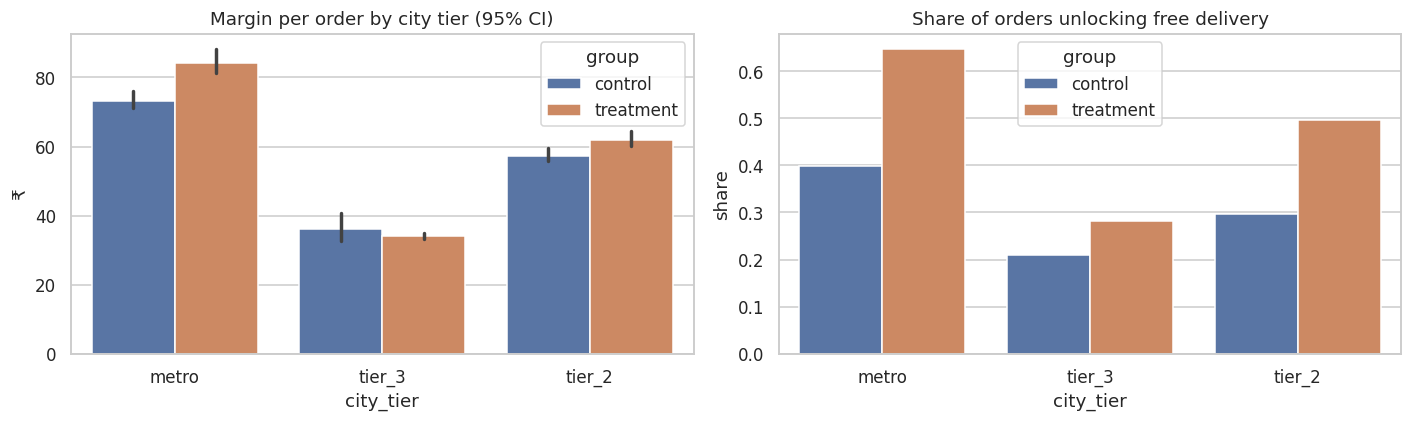

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=post, x="city_tier", y="margin_inr", hue="group", errorbar=("ci", 95), ax=axes[0])
axes[0].set(title="Margin per order by city tier (95% CI)", ylabel="₹")
sns.barplot(data=post, x="city_tier", y="free_delivery_unlocked", hue="group",
            errorbar=None, ax=axes[1])
axes[1].set(title="Share of orders unlocking free delivery", ylabel="share")
plt.tight_layout()

Tier-3 is the problem child: the highest delivery cost (~₹60 per run) and the lowest
baskets, so the nudge hands out free delivery on orders that were never going to carry
it. Metro is the opposite — baskets are already near the threshold, so the nudge
converts small top-ups into large margin gains.

## 6. Novelty — is the lift decaying?

A cart banner is new for exactly as long as it is new. If week 1's lift is much larger
than week 4's, the pooled estimate over-forecasts the steady state, and any annualised
projection built on it will be wrong.

In [17]:
post = post.copy()
post["week"] = ((post["order_ts"] - post["order_ts"].min()).dt.days // 7 + 1).clip(1, 4)
weekly = post.pivot_table(index="week", columns="group", values="basket_value_inr", aggfunc="mean")
weekly["lift"] = weekly["treatment"] - weekly["control"]
weekly

group,control,treatment,lift
week,,,
1,436.81,542.00,105.19
2,463.81,515.65,51.84
3,453.70,531.35,77.65
4,436.82,501.62,64.80


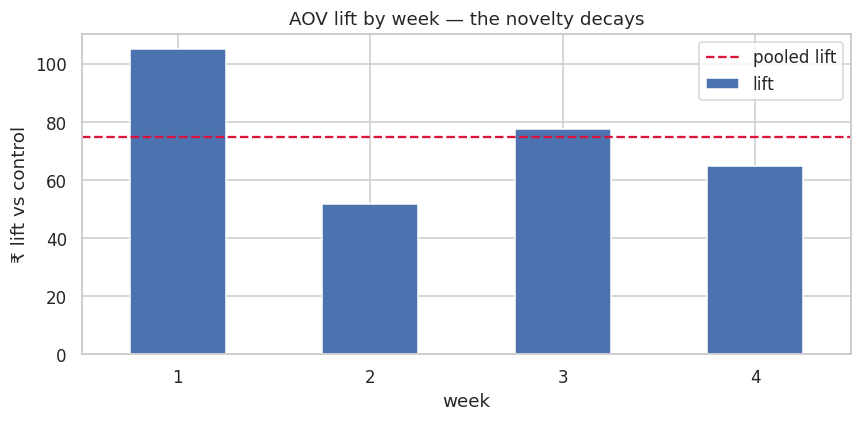

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
weekly["lift"].plot(kind="bar", ax=ax, color="#4C72B0", rot=0)
ax.axhline(weekly["lift"].mean(), color="crimson", ls="--", label="pooled lift")
ax.set(title="AOV lift by week — the novelty decays", ylabel="₹ lift vs control", xlabel="week")
ax.legend()
plt.tight_layout()

Week 1 is by far the largest and the trend is downward, though weekly noise is clearly
visible — week 3 sits above week 2. With ~13,000 orders per arm per week the standard
error on a weekly AOV lift is around ₹15, so individual weeks should not be over-read.
The direction is the point: the pooled number over-states the steady state, so notebook
04 forecasts off weeks 3–4 instead.

## 7. Pre-period balance — the baseline for the paired test

The paired t-test in notebook 04 compares a loyal user's basket **before** launch to
their basket **during** the experiment. That is only meaningful if the two arms were
indistinguishable before the nudge existed.

In [19]:
pre_user = (
    clean[clean["phase"] == "pre"]
    .groupby(["user_id", "group"])
    .agg(n_pre_orders=("order_id", "size"), pre_mean_basket=("basket_value_inr", "mean"))
    .reset_index()
)
post_user = (
    clean[clean["phase"] == "post"]
    .groupby(["user_id", "group"])
    .agg(post_mean_basket=("basket_value_inr", "mean"))
    .reset_index()
)

# Same cohort definition notebook 04 pairs on: >= 3 pre-period orders AND an order in the test.
cohort = pre_user[pre_user["n_pre_orders"] >= 3].merge(post_user, on=["user_id", "group"])
print(f"paired cohort: {cohort.groupby('group').size().to_dict()}")

t_stat, p_val = stats.ttest_ind(
    cohort.loc[cohort["group"] == "treatment", "pre_mean_basket"],
    cohort.loc[cohort["group"] == "control", "pre_mean_basket"],
    equal_var=False,
)
print(f"pre-period basket, treatment vs control: t = {t_stat:+.2f}, p = {p_val:.3f}")
cohort.groupby("group")["pre_mean_basket"].agg(["size", "mean", "std"])

paired cohort: {'control': 547, 'treatment': 520}
pre-period basket, treatment vs control: t = -0.03, p = 0.979


,size,mean,std
group,,,
control,547,435.95,123.52
treatment,520,435.75,125.91


p ≈ 0.98 — the arms were indistinguishable before the nudge existed. Any pre-to-post
movement that shows up only in the treatment arm can therefore be attributed to it.

This is the baseline the paired t-test in notebook 04 rests on, and it is worth being
strict about: a paired before/after design is only as good as the claim that nothing
else changed. The control arm, tested the same way, is what makes that claim checkable.

## What carries into notebook 04

| | |
| --- | --- |
| Continuous metrics | revenue per session, **margin per session**, AOV among converters |
| Cleaning | drop 250 orphan sessions and ~0.3% missing baskets; keep the 12 bulk orders |
| Test | **Welch** two-sample t-test (unequal variances) + **paired** t-test on the loyal cohort |
| Distribution | right-skewed, near-lognormal — CLT applies at this n, verified by bootstrap |
| Watch | free delivery unlocked 32% → 52%; tier-3 delivery cost ≈ ₹60 |
| Watch | novelty decay — forecast from weeks 3–4, not the pooled mean |